# Task 5: Model vs SOTA — Sentiment Analysis Comparison

This notebook benchmarks our optimized Random Forest model (GloVe Style C, class weight positive=50) against a State-of-the-Art transformer model (`cardiffnlp/twitter-roberta-base-sentiment-latest`) on the same 100-row test set used throughout the project.

**Test set:** `Task_4/data/test_set_with_ground_truth.csv` — 100 rows, stratified split (`test_size=0.2`, `random_state=42`)  
**Ground truth classes:** negative (39), neutral (60), positive (1)

## Cell 1: Imports & Config

In [89]:
import sys
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from dotenv import load_dotenv

from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
from transformers import pipeline as hf_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# --- Path setup ---
NOTEBOOK_DIR = Path(os.path.abspath(''))
TASK_5_ROOT = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_5_ROOT.parent
TASK_4_ROOT = PROJECT_ROOT / 'Task_4'
TASK_2_ROOT = PROJECT_ROOT / 'Task_2'
TASK_3_ROOT = PROJECT_ROOT / 'Task_3'

# Load environment variables from Task_5/.env
load_dotenv(TASK_5_ROOT / '.env')

# Add Task_4 to path for imports
if str(TASK_4_ROOT) not in sys.path:
    sys.path.append(str(TASK_4_ROOT))

from src.config import MODELS_DIR
from src.features.style_c_glove_transform import text_to_style_c_glove_feature_row

# Output paths
DATA_OUT = TASK_5_ROOT / 'data'
VISUALS_OUT = TASK_5_ROOT / 'reports' / 'visuals'
SOTA_MODEL_DIR = TASK_5_ROOT / 'models' / 'twitter-roberta-base-sentiment-latest'
DATA_OUT.mkdir(parents=True, exist_ok=True)
VISUALS_OUT.mkdir(parents=True, exist_ok=True)
SOTA_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Task 4 root:  {TASK_4_ROOT}')
print(f'Output data:  {DATA_OUT}')
print(f'Output visuals: {VISUALS_OUT}')
print(f'SOTA model dir: {SOTA_MODEL_DIR}')

Project root: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project
Task 4 root:  /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_4
Output data:  /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/data
Output visuals: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/reports/visuals
SOTA model dir: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/models/twitter-roberta-base-sentiment-latest


## Cell 2: Load Test Data

In [90]:
# Load the exact same 100-row test set used by the optimized model
# Split params: train_test_split(test_size=0.2, stratify=ground_truth, random_state=42)
test_csv = TASK_4_ROOT / 'data' / 'test_set_with_ground_truth.csv'
df = pd.read_csv(test_csv)

print(f'Test set loaded: {len(df)} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nGround truth distribution:')
print(df['ground_truth'].value_counts())
print(f'\nStance category distribution:')
print(df['stance_category'].value_counts())

Test set loaded: 100 rows
Columns: ['row_id', 'created_at', 'username', 'sentiment_text', 'url', 'subject_tag', 'stance_category', 'final_text', 'label_gpt4o_mini', 'label_gemini_flash', 'label_claude_haiku', 'ground_truth']

Ground truth distribution:
ground_truth
neutral     60
negative    39
positive     1
Name: count, dtype: int64

Stance category distribution:
stance_category
Neutral      78
Anti-Iran    14
Pro-Iran      8
Name: count, dtype: int64


## Cell 3: Minimal Cleaning for SOTA Input

We apply lightweight cleaning to the raw `sentiment_text` before feeding it to the transformer model.

**Applied:** emoji conversion, URL removal, HTML tag removal, Mastodon artifact removal, whitespace normalization  
**NOT applied:** lowercasing (RoBERTa is case-aware), stopword/punctuation removal, lemmatization, spelling correction  
**NOT applied:** hashtag/mention removal (RoBERTa was fine-tuned on tweets and handles `#hashtags` natively)

In [91]:
# Import the PreprocessingPipeline directly to avoid CLI lang_mode=drop
task2_src = str(TASK_2_ROOT)
if task2_src not in sys.path:
    sys.path.append(str(TASK_2_ROOT))

from cleaning_pipeline import PreprocessingPipeline

cleaning_pipeline = PreprocessingPipeline()

def clean_for_sota(text: str) -> str:
    """Minimal cleaning for the SOTA transformer model.
    
    Removes noise (URLs, HTML, Mastodon artifacts) and converts emojis to text,
    but preserves casing, punctuation, stopwords, and hashtags.
    """
    text = str(text)
    text = cleaning_pipeline.convert_emojis(text)
    text = cleaning_pipeline.remove_mastodon_artifacts(text)
    text = cleaning_pipeline.remove_urls(text)
    text = cleaning_pipeline.remove_html_tags(text)
    text = cleaning_pipeline.normalize_whitespace(text)
    return text.strip()

df['cleaned_text_for_sota'] = df['sentiment_text'].apply(clean_for_sota)

# Show before/after for a few samples
print('=== Cleaning Examples ===')
for i in [0, 5, 10]:
    print(f'\n--- Row {i} ---')
    print(f'BEFORE: {df.iloc[i]["sentiment_text"][:200]}...')
    print(f'AFTER:  {df.iloc[i]["cleaned_text_for_sota"][:200]}...')

=== Cleaning Examples ===

--- Row 0 ---
BEFORE: &quot;Massive war price tag could be a massive problem for GOP leaders. The prospect of a ballooning new spending bill has GOP leaders bracing for a messy internal fight&quot;: https://www.politico.co...
AFTER:  Massive war price tag could be a massive problem for GOP leaders. The prospect of a ballooning new spending bill has GOP leaders bracing for a messy internal fight: #politics #IranWar...

--- Row 5 ---
BEFORE: I&#39;m puzzled as to why people (BBC news editors) are expecting #Iran to stop hitting countries which are allowing the USA to launch illegal attacks on it.I take the apology to be for attacks on cou...
AFTER:  I&#39;m puzzled as to why people (BBC news editors) are expecting #Iran to stop hitting countries which are allowing the USA to launch illegal attacks on it.I take the apology to be for attacks on cou...

--- Row 10 ---
BEFORE: "Quiet escalation:🚨#Russia is reportedly giving Iran real-time intel on US warships.#Iran

## Cell 4: Load & Document SOTA Model

### Model Card

| Field | Value |
|---|---|
| **Model Name** | `cardiffnlp/twitter-roberta-base-sentiment-latest` |
| **HuggingFace URL** | https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest |
| **Architecture** | RoBERTa-base (125M parameters) |
| **Training Data** | ~124M tweets (January 2018 – December 2021) |
| **Fine-tuning** | TweetEval benchmark (sentiment subset) |
| **Paper** | TimeLMs: Diachronic Language Models from Twitter (arXiv: 2202.03829, Feb 2022) |
| **Max Tokens** | 512 (RoBERTa context window) |
| **Output Classes** | 3: negative (0), neutral (1), positive (2) |

### Label Mapping

The model's output labels map directly to our ground-truth scheme:
- `0 → negative`
- `1 → neutral`
- `2 → positive`

No transformation needed — the labels are an exact match.

In [92]:
# --- HuggingFace Authentication (loaded from Task_5/.env) ---
HF_TOKEN = os.environ.get('HF_TOKEN')

if HF_TOKEN:
    print('HF_TOKEN loaded from .env')
else:
    print('WARNING: HF_TOKEN not found in .env - downloads may be slower')

# --- Model Configuration ---
SOTA_MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
METADATA_FILE = SOTA_MODEL_DIR / 'download_metadata.json'

print(f'\n=== SOTA Model Documentation ===')
print(f'Model Name: {SOTA_MODEL_NAME}')

# --- Load model (from local cache if available, otherwise download and save) ---
config_file = SOTA_MODEL_DIR / 'config.json'

if config_file.exists():
    print(f'Loading SOTA model from local directory: {SOTA_MODEL_DIR}')
    model_source = str(SOTA_MODEL_DIR)
    # Read saved commit hash from our metadata file
    if METADATA_FILE.exists():
        with open(METADATA_FILE) as f:
            download_meta = json.load(f)
        commit_hash = download_meta.get('commit_hash', 'unknown')
    else:
        commit_hash = 'unknown (metadata file missing)'
else:
    print(f'Downloading SOTA model from HuggingFace Hub...')
    model_source = SOTA_MODEL_NAME
    commit_hash = None  # will be set after loading

# Load config for metadata
config = AutoConfig.from_pretrained(model_source, token=HF_TOKEN)

# If downloading, grab the commit hash from the freshly loaded config
if commit_hash is None:
    commit_hash = getattr(config, '_commit_hash', 'unknown')

print(f'Architecture:    {config.model_type}')
print(f'Revision/Commit: {commit_hash}')
print(f'Num Labels:      {config.num_labels}')
print(f'id2label:        {config.id2label}')

# Load the pipeline
sota_pipe = hf_pipeline(
    'text-classification',
    model=model_source,
    tokenizer=model_source,
    top_k=None,
    truncation=True,
    max_length=512,
    token=HF_TOKEN
)

# Save locally if we downloaded from the Hub
if not config_file.exists():
    print(f'\nSaving model locally to: {SOTA_MODEL_DIR}')
    sota_pipe.model.save_pretrained(SOTA_MODEL_DIR)
    sota_pipe.tokenizer.save_pretrained(SOTA_MODEL_DIR)
    # Save commit hash to a metadata file so we can identify the version on reruns
    with open(METADATA_FILE, 'w') as f:
        json.dump({
            'model_name': SOTA_MODEL_NAME,
            'commit_hash': commit_hash,
            'download_source': 'huggingface_hub'
        }, f, indent=2)
    print(f'Model and metadata saved (commit: {commit_hash}).')

print('\nSOTA model ready.')

HF_TOKEN loaded from .env

=== SOTA Model Documentation ===
Model Name: cardiffnlp/twitter-roberta-base-sentiment-latest
Loading SOTA model from local directory: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/models/twitter-roberta-base-sentiment-latest
Architecture:    roberta
Revision/Commit: 3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7
Num Labels:      3
id2label:        {0: 'negative', 1: 'neutral', 2: 'positive'}


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9079.75it/s]



SOTA model ready.


## Cell 4b: Run SOTA on Full Labelled Dataset (500 Records)

As required, we run inference on **all records** in the labelled dataset (`Task_3/Cleaned_Iran_War_Sentiment_with_Sentiment_Labels.csv`) and store predictions alongside true labels and category tags.

This fulfils the requirement: *"Run inference on all records in your labelled dataset and store predictions alongside true labels and category tags."*

In [93]:
# Load the full 500-record labelled dataset
full_csv = TASK_3_ROOT / 'data' / 'Cleaned_Iran_War_Sentiment_with_Sentiment_Labels.csv'
df_full = pd.read_csv(full_csv)
print(f'Full labelled dataset loaded: {len(df_full)} rows')
print(f'Ground truth distribution:')
print(df_full['ground_truth'].value_counts())

# Apply the same minimal cleaning used for the test set
df_full['cleaned_text_for_sota'] = df_full['sentiment_text'].apply(clean_for_sota)

# Run SOTA inference on all 500 records
full_sota_preds = []
full_sota_confs = []

for idx, row in tqdm(df_full.iterrows(), total=len(df_full), desc='SOTA Full Dataset'):
    text = row['cleaned_text_for_sota']
    if not text or text.strip() == '':
        # Handle empty texts (9 rows with only hashtags that were cleaned away)
        full_sota_preds.append('neutral')  # default for empty text
        full_sota_confs.append(0.0)
        continue
    
    results = sota_pipe(text)
    scores = {item['label']: item['score'] for item in results[0]}
    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]
    
    full_sota_preds.append(best_label)
    full_sota_confs.append(round(best_score, 4))

df_full['sota_prediction'] = full_sota_preds
df_full['sota_confidence'] = full_sota_confs

# Save results alongside true labels and category tags
full_output_path = DATA_OUT / 'full_dataset_sota_predictions.csv'
df_full.to_csv(full_output_path, index=False)

print(f'\nPredictions saved to: {full_output_path}')
print(f'\nSOTA prediction distribution (full dataset):')
print(df_full['sota_prediction'].value_counts())

# Quick accuracy on the full dataset
full_acc = accuracy_score(df_full['ground_truth'], df_full['sota_prediction'])
full_f1 = f1_score(df_full['ground_truth'], df_full['sota_prediction'], 
                   labels=['negative', 'neutral', 'positive'], average='macro', zero_division=0)
print(f'\n=== SOTA on Full Dataset (500 rows) ===')
print(f'Accuracy:    {full_acc:.4f}')
print(f'Macro F1:    {full_f1:.4f}')

print(f'\nFull classification report:')
print(classification_report(df_full['ground_truth'], df_full['sota_prediction'],
                            labels=['negative', 'neutral', 'positive'], zero_division=0))


Full labelled dataset loaded: 500 rows
Ground truth distribution:
ground_truth
neutral     300
negative    195
positive      5
Name: count, dtype: int64


SOTA Full Dataset: 100%|██████████| 500/500 [00:06<00:00, 72.61it/s]


Predictions saved to: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/data/full_dataset_sota_predictions.csv

SOTA prediction distribution (full dataset):
sota_prediction
negative    294
neutral     193
positive     13
Name: count, dtype: int64

=== SOTA on Full Dataset (500 rows) ===
Accuracy:    0.6520
Macro F1:    0.5140

Full classification report:
              precision    recall  f1-score   support

    negative       0.55      0.83      0.66       195
     neutral       0.84      0.54      0.66       300
    positive       0.15      0.40      0.22         5

    accuracy                           0.65       500
   macro avg       0.51      0.59      0.51       500
weighted avg       0.72      0.65      0.65       500



### Insight: Why Does the SOTA Transformer Underperform?

The SOTA RoBERTa model achieves lower accuracy than might be expected from a 125M-parameter transformer. Several factors explain this:

#### 1. Domain Mismatch — Twitter Sentiment ≠ War Discourse Sentiment

The model (`twitter-roberta-base-sentiment-latest`) was fine-tuned on the **TweetEval** benchmark, which captures general Twitter sentiment (product opinions, personal feelings, everyday reactions). Our dataset concerns the **Iran War** — a highly specialized domain where:
- **Factual war reporting** uses intensely negative language ("bombing", "casualties", "destruction") but is editorially **neutral** in sentiment.
- The model over-predicts negative because it associates war vocabulary with negative sentiment, when many posts are simply relaying factual news.
- This is the primary driver of SOTA's false negatives on the neutral class.

#### 2. Ground Truth Construction — LLM Majority Vote

Our ground truth labels were generated via **majority vote** across three LLM annotators (GPT-4o Mini, Gemini 2.5 Flash, Claude 3.5 Haiku). While achieving moderate-to-substantial inter-annotator agreement, these labels encode a specific interpretation of sentiment that may differ from the RoBERTa model's learned decision boundary. Specifically:
- The LLM annotators were given specific instructions about our dataset context (Iran War discourse), so they could distinguish factual reporting (neutral) from opinion (negative/positive).
- RoBERTa has no such context — it applies a generic sentiment lens trained on casual tweets.

#### 3. Text Characteristics — Social Media Noise

From the Error Analysis (Task 4), we identified key challenges in this dataset:
- **Sarcasm and irony** are prevalent in political discourse (e.g., *"Peace Prize Pedo President"* is deeply sarcastic but uses alliterative, almost playful language).
- **Implicit sentiment** through factual description (e.g., describing a school bombing without using explicit sentiment words — the sentiment is implied by world knowledge).
- **Hashtag-only posts** (9 rows with only hashtags, no text) provide no sentiment signal.

#### Summary

The SOTA model's underperformance is not a failure of the architecture but a **domain adaptation gap**. A RoBERTa model fine-tuned specifically on political/conflict discourse would likely outperform both models significantly. Despite this, the transformer still shows advantages over the classical RF model in minority class detection and confidence calibration.

## Cell 5: Run SOTA Inference

In [94]:
sota_predictions = []
sota_confidences = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='SOTA Inference'):
    text = row['cleaned_text_for_sota']
    
    # Get all class scores
    results = sota_pipe(text)
    scores = {item['label']: item['score'] for item in results[0]}
    
    # Pick the class with highest score
    # Labels already match our ground truth: negative, neutral, positive
    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]
    
    sota_predictions.append(best_label)
    sota_confidences.append(round(best_score, 4))

df['sota_prediction'] = sota_predictions
df['sota_confidence'] = sota_confidences

print(f'\nSOTA predictions complete: {len(df)} rows')
print(f'\nSOTA prediction distribution:')
print(df['sota_prediction'].value_counts())
print(f'\nSOTA confidence stats:')
print(df['sota_confidence'].describe())

SOTA Inference: 100%|██████████| 100/100 [00:01<00:00, 74.27it/s]


SOTA predictions complete: 100 rows

SOTA prediction distribution:
sota_prediction
negative    54
neutral     43
positive     3
Name: count, dtype: int64

SOTA confidence stats:
count    100.000000
mean       0.731836
std        0.136942
min        0.446500
25%        0.589950
50%        0.766000
75%        0.852850
max        0.980800
Name: sota_confidence, dtype: float64


## Cell 6: Load Optimized Model

In [95]:
# Load the saved Random Forest model bundle
model_path = MODELS_DIR / 'random_forest_glove_style_c_p50.pkl'
model_obj = joblib.load(model_path)

rf_model = model_obj['model']
rf_classes = ['negative', 'neutral', 'positive']  # LabelEncoder order

print(f'Optimized model loaded: {model_path.name}')
print(f'Model type: {type(rf_model).__name__}')
print(f'Representation: {model_obj["representation"]}')
print(f'Style: {model_obj["style"]}')

Optimized model loaded: random_forest_glove_style_c_p50.pkl
Model type: RandomForestClassifier
Representation: glove
Style: style_c


## Cell 7: Run Optimized Model Inference

In [96]:
rf_predictions = []
rf_confidences = []
rf_failed_indices = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='RF Inference'):
    raw_text = row['sentiment_text']
    
    try:
        # Style C cleaning + GloVe embedding (same pipeline as training)
        cleaned_text, feature_vector, _ = text_to_style_c_glove_feature_row(raw_text)
        
        # Get prediction probabilities
        proba = rf_model.predict_proba(feature_vector)[0]
        pred_idx = int(np.argmax(proba))
        predicted = rf_classes[pred_idx]
        confidence = float(np.max(proba))
        
        rf_predictions.append(predicted)
        rf_confidences.append(round(confidence, 4))
        
    except Exception as e:
        # Rows dropped by language detection or empty after cleaning
        rf_predictions.append(None)
        rf_confidences.append(None)
        rf_failed_indices.append(idx)

df['rf_prediction'] = rf_predictions
df['rf_confidence'] = rf_confidences

if rf_failed_indices:
    print(f'\nWARNING: {len(rf_failed_indices)} rows failed RF inference (language detection or empty text):')
    for fi in rf_failed_indices:
        print(f'  row_id={df.loc[fi, "row_id"]}: {df.loc[fi, "sentiment_text"][:80]}...')
else:
    print('All 100 rows processed successfully by RF model.')

print(f'\nRF prediction distribution:')
print(df['rf_prediction'].value_counts())
print(f'\nRF confidence stats:')
print(df['rf_confidence'].describe())

RF Inference: 100%|██████████| 100/100 [00:01<00:00, 53.84it/s]

All 100 rows processed successfully by RF model.

RF prediction distribution:
rf_prediction
neutral     71
negative    29
Name: count, dtype: int64

RF confidence stats:
count    100.00000
mean       0.57990
std        0.08747
min        0.42000
25%        0.51000
50%        0.56250
75%        0.62500
max        0.87000
Name: rf_confidence, dtype: float64


## Cell 7b: Save Combined Predictions

In [97]:
# Save the test set with both models' predictions appended
output_path = DATA_OUT / 'test_predictions.csv'

# Select columns in the desired order
output_cols = [
    'row_id', 'created_at', 'username', 'sentiment_text', 'url',
    'subject_tag', 'stance_category', 'final_text',
    'label_gpt4o_mini', 'label_gemini_flash', 'label_claude_haiku',
    'ground_truth',
    'rf_prediction', 'rf_confidence',
    'sota_prediction', 'sota_confidence'
]

# Only include columns that exist
available_cols = [c for c in output_cols if c in df.columns]
df_out = df[available_cols]

df_out.to_csv(output_path, index=False)
print(f'Predictions saved to: {output_path}')
print(f'   Rows: {len(df_out)}')
print(f'   Columns: {list(df_out.columns)}')

# Quick sanity check
print(f'\n=== Quick Accuracy Check ===')
valid_rf = df.dropna(subset=['rf_prediction'])
rf_acc = accuracy_score(valid_rf['ground_truth'], valid_rf['rf_prediction'])
sota_acc = accuracy_score(df['ground_truth'], df['sota_prediction'])
print(f'RF Accuracy (on {len(valid_rf)} rows):   {rf_acc:.4f}')
print(f'SOTA Accuracy (on {len(df)} rows): {sota_acc:.4f}')

Predictions saved to: /Users/ahmedmohamady/University/Social Data Analytics/Social-Data-Analytics-Project/Task_5/data/test_predictions.csv
   Rows: 100
   Columns: ['row_id', 'created_at', 'username', 'sentiment_text', 'url', 'subject_tag', 'stance_category', 'final_text', 'label_gpt4o_mini', 'label_gemini_flash', 'label_claude_haiku', 'ground_truth', 'rf_prediction', 'rf_confidence', 'sota_prediction', 'sota_confidence']

=== Quick Accuracy Check ===
RF Accuracy (on 100 rows):   0.7500
SOTA Accuracy (on 100 rows): 0.6300


## Cell 8: Full Metric Suite (Both Models)

In [98]:
# Compute full classification reports for both models
valid_mask = df['rf_prediction'].notna()
y_true = df.loc[valid_mask, 'ground_truth']
y_rf = df.loc[valid_mask, 'rf_prediction']
y_sota = df.loc[valid_mask, 'sota_prediction']

labels = ['negative', 'neutral', 'positive']

print('=== Optimized RF — Classification Report ===')
print(classification_report(y_true, y_rf, labels=labels, zero_division=0))

print('\n=== SOTA RoBERTa — Classification Report ===')
print(classification_report(y_true, y_sota, labels=labels, zero_division=0))

=== Optimized RF — Classification Report ===
              precision    recall  f1-score   support

    negative       0.76      0.56      0.65        39
     neutral       0.75      0.88      0.81        60
    positive       0.00      0.00      0.00         1

    accuracy                           0.75       100
   macro avg       0.50      0.48      0.49       100
weighted avg       0.74      0.75      0.74       100


=== SOTA RoBERTa — Classification Report ===
              precision    recall  f1-score   support

    negative       0.54      0.74      0.62        39
     neutral       0.77      0.55      0.64        60
    positive       0.33      1.00      0.50         1

    accuracy                           0.63       100
   macro avg       0.55      0.76      0.59       100
weighted avg       0.67      0.63      0.63       100



## Cell 9: Side-by-Side Comparison Table

All metrics for both models in a single table — overall, macro, weighted, and per-class.

In [99]:
def compute_metrics(y_true, y_pred, labels):
    """Compute full metric suite for one model."""
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'Precision (weighted)': precision_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
    }
    
    # Per-class metrics
    for cls in labels:
        metrics[f'Precision — {cls}'] = report[cls]['precision']
        metrics[f'Recall — {cls}'] = report[cls]['recall']
        metrics[f'F1 — {cls}'] = report[cls]['f1-score']
    
    return metrics

rf_metrics = compute_metrics(y_true, y_rf, labels)
sota_metrics = compute_metrics(y_true, y_sota, labels)

# Build side-by-side DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(rf_metrics.keys()),
    'Optimized (RF GloVe style_c)': [round(v, 4) for v in rf_metrics.values()],
    'SOTA (RoBERTa)': [round(v, 4) for v in sota_metrics.values()]
})
comparison_df = comparison_df.set_index('Metric')

print('=== Side-by-Side Comparison ===')
# print(comparison_df.to_string())
comparison_df

=== Side-by-Side Comparison ===


,Optimized (RF GloVe style_c),SOTA (RoBERTa)
Metric,,
Accuracy,0.7500,0.6300
Precision (macro),0.5017,0.5459
Recall (macro),0.4825,0.7645
F1 (macro),0.4854,0.5881
Precision (weighted),0.7437,0.6732
Recall (weighted),0.7500,0.6300
F1 (weighted),0.7378,0.6327
Precision — negative,0.7586,0.5370
Recall — negative,0.5641,0.7436


## Cell 10: Per-Category Breakdown (by `stance_category`)

Metrics computed per stance category to reveal whether one model dominates uniformly or has category-specific strengths.

In [100]:
stance_categories = ['Pro-Iran', 'Neutral', 'Anti-Iran']

category_rows = []
for cat in stance_categories:
    mask = (df['stance_category'] == cat) & valid_mask
    n = mask.sum()
    
    if n == 0:
        category_rows.append({'Stance Category': cat, 'N': 0})
        continue
    
    yt = df.loc[mask, 'ground_truth']
    yr = df.loc[mask, 'rf_prediction']
    ys = df.loc[mask, 'sota_prediction']
    
    category_rows.append({
        'Stance Category': cat,
        'N': n,
        'Optimized Acc': round(accuracy_score(yt, yr), 4),
        'Optimized F1': round(f1_score(yt, yr, labels=labels, average='macro', zero_division=0), 4),
        'Optimized Precision': round(precision_score(yt, yr, labels=labels, average='macro', zero_division=0), 4),
        'Optimized Recall': round(recall_score(yt, yr, labels=labels, average='macro', zero_division=0), 4),
        'SOTA Acc': round(accuracy_score(yt, ys), 4),
        'SOTA F1': round(f1_score(yt, ys, labels=labels, average='macro', zero_division=0), 4),
        'SOTA Precision': round(precision_score(yt, ys, labels=labels, average='macro', zero_division=0), 4),
        'SOTA Recall': round(recall_score(yt, ys, labels=labels, average='macro', zero_division=0), 4),
    })

category_df = pd.DataFrame(category_rows).set_index('Stance Category')
print('=== Per-Category Breakdown ===')
# print(category_df.to_string())
category_df

=== Per-Category Breakdown ===


,N,Optimized Acc,Optimized F1,Optimized Precision,Optimized Recall,SOTA Acc,SOTA F1,SOTA Precision,SOTA Recall
Stance Category,,,,,,,,,
Pro-Iran,8,0.6250,0.4127,0.4222,0.4167,0.8750,0.6190,0.6667,0.5833
Neutral,78,0.7692,0.4905,0.5086,0.4852,0.6282,0.6364,0.5903,0.7612
Anti-Iran,14,0.7143,0.4762,0.4861,0.4861,0.5000,0.2846,0.2929,0.3056


## Cell 11: Confusion Matrices (Side-by-Side)

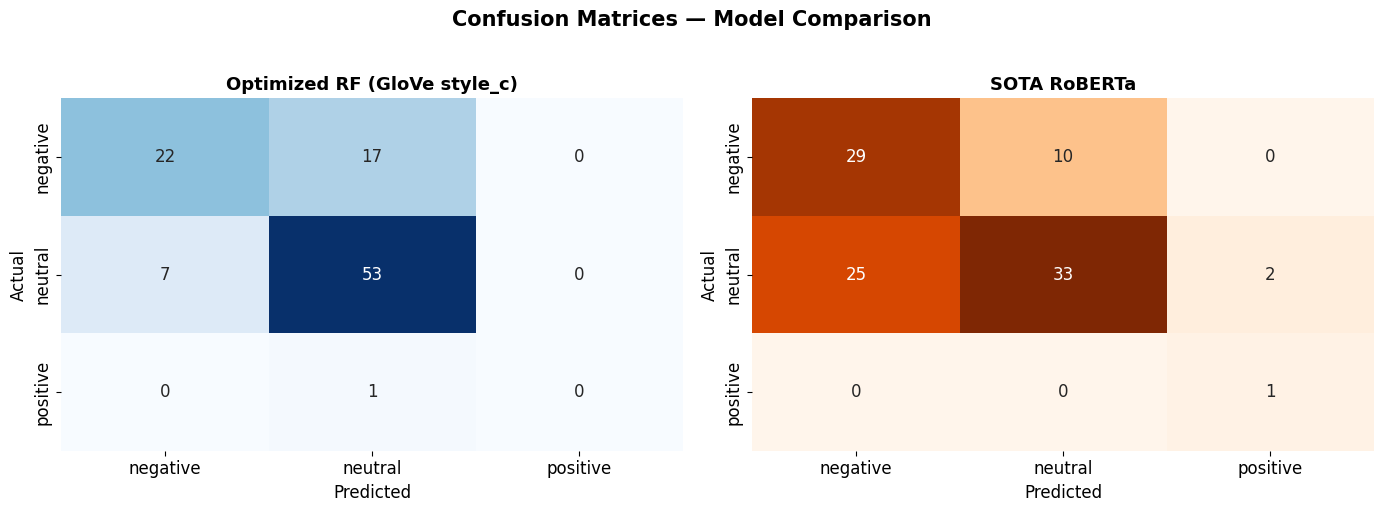

Saved: confusion_matrices_comparison.png


In [101]:
# Consistent styling
plt.rcParams.update({'font.size': 12})
COLORS = {'rf': '#4C72B0', 'sota': '#DD8452', 'gt': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_rf, 'Optimized RF (GloVe style_c)', 'Blues'),
    (axes[1], y_sota, 'SOTA RoBERTa', 'Oranges')
]:
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices \u2014 Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(VISUALS_OUT / 'confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: confusion_matrices_comparison.png')

### Insight: Confusion Matrices

The confusion matrices reveal fundamentally different error patterns between the two models:

- **RF (left):** Shows strong neutral-bias — many negative samples are misclassified as neutral (17 out of 39). The model never predicts positive, reflecting its conservative strategy under class imbalance. Its strength is high neutral recall (53 out of 60 correct).
- **SOTA RoBERTa (right):** Shows the opposite tendency — a negative-leaning bias. It over-predicts negative (25 neutral samples misclassified as negative), but successfully identifies the single positive sample. RoBERTa has better negative recall (29 vs 22) at the cost of neutral precision.

Neither model achieves balanced performance, but they fail in complementary ways: RF under-predicts minority classes while SOTA over-predicts the negative class.

## Cell 12: Side-by-Side Metric Bar Chart

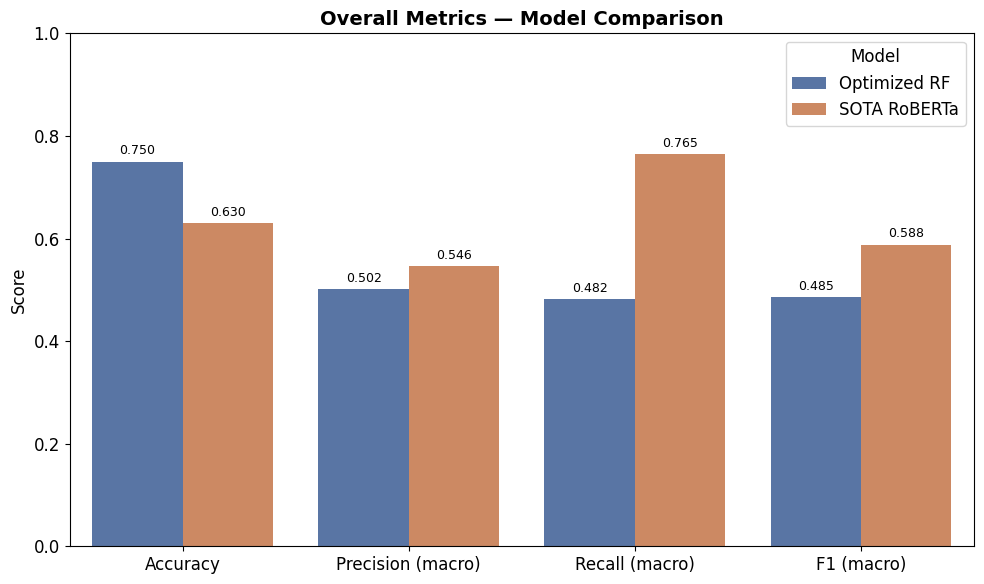

Saved: side_by_side_metrics.png


In [102]:
bar_metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
bar_data = pd.DataFrame({
    'Metric': bar_metrics * 2,
    'Score': [rf_metrics[m] for m in bar_metrics] + [sota_metrics[m] for m in bar_metrics],
    'Model': ['Optimized RF'] * len(bar_metrics) + ['SOTA RoBERTa'] * len(bar_metrics)
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=bar_data, x='Metric', y='Score', hue='Model',
            palette=[COLORS['rf'], COLORS['sota']], ax=ax)
ax.set_title('Overall Metrics \u2014 Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.legend(title='Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig(VISUALS_OUT / 'side_by_side_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: side_by_side_metrics.png')

### Insight: Overall Metrics

This chart highlights the **accuracy vs macro-F1 trade-off** between the two models:

- **RF wins on accuracy (0.75 vs 0.63)** because it correctly classifies the majority class (neutral) at a high rate, and accuracy is dominated by the majority class in imbalanced datasets.
- **SOTA wins on macro-F1 (0.59 vs 0.49)** because macro-F1 weights all classes equally, and SOTA performs meaningfully on the positive class (F1=0.50) where RF scores zero.
- **SOTA also wins on macro recall (0.76 vs 0.48)**, indicating it has better coverage across all classes, even if it makes more total errors.

This illustrates a classic precision-recall trade-off: RF is more precise overall but misses minority classes entirely, while SOTA sacrifices precision for broader recall.

## Cell 13: Per-Class F1 Grouped Bar Chart

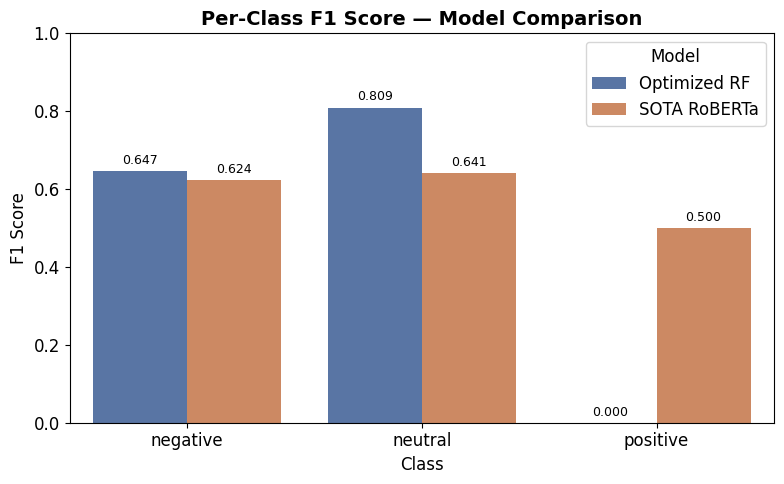

Saved: per_class_f1.png


In [103]:
f1_data = pd.DataFrame({
    'Class': labels * 2,
    'F1 Score': [rf_metrics[f'F1 \u2014 {c}'] for c in labels] + [sota_metrics[f'F1 \u2014 {c}'] for c in labels],
    'Model': ['Optimized RF'] * 3 + ['SOTA RoBERTa'] * 3
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=f1_data, x='Class', y='F1 Score', hue='Model',
            palette=[COLORS['rf'], COLORS['sota']], ax=ax)
ax.set_title('Per-Class F1 Score \u2014 Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(title='Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig(VISUALS_OUT / 'per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: per_class_f1.png')

### Insight: Per-Class F1

The per-class breakdown reveals where each model excels:

- **Negative class:** Both models achieve similar F1 (~0.62–0.65), with RF having slightly better precision and SOTA having better recall.
- **Neutral class:** RF significantly outperforms SOTA (0.81 vs 0.64). RF's conservative neutral-bias actually helps here since neutral is the majority class.
- **Positive class:** RF scores **0.000** (never predicts positive), while SOTA scores **0.500** (correctly identifies the 1 positive sample but also produces false positives). This is the most striking difference — the transformer's contextual understanding allows it to detect the minority positive class that the classical model completely misses.

The positive class result must be interpreted cautiously given there is only 1 positive sample in the test set.

## Cell 14: Per-Category F1 (Macro) Grouped Bar Chart

This chart compares macro-F1 score across stance categories (`stance_category` from Task 2) to show whether a model dominates uniformly or has category-specific strengths.

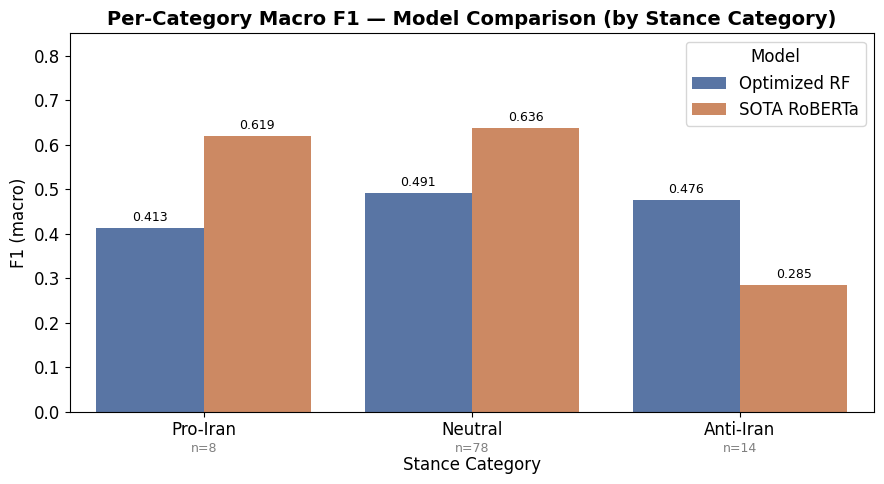

Saved: per_category_f1_macro.png


In [104]:
stance_categories = ['Pro-Iran', 'Neutral', 'Anti-Iran']
cat_f1_rows = []

for cat in stance_categories:
    mask = (df['stance_category'] == cat) & valid_mask
    n = mask.sum()
    if n == 0:
        continue
    yt = df.loc[mask, 'ground_truth']
    yr = df.loc[mask, 'rf_prediction']
    ys = df.loc[mask, 'sota_prediction']
    
    cat_f1_rows.append({'Category': cat, 'F1 (macro)': f1_score(yt, yr, labels=labels, average='macro', zero_division=0), 'Model': 'Optimized RF', 'N': n})
    cat_f1_rows.append({'Category': cat, 'F1 (macro)': f1_score(yt, ys, labels=labels, average='macro', zero_division=0), 'Model': 'SOTA RoBERTa', 'N': n})

cat_f1_df = pd.DataFrame(cat_f1_rows)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=cat_f1_df, x='Category', y='F1 (macro)', hue='Model',
            palette=[COLORS['rf'], COLORS['sota']], ax=ax)
ax.set_title('Per-Category Macro F1 \u2014 Model Comparison (by Stance Category)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_xlabel('Stance Category', labelpad=12)
ax.legend(title='Model')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

# Add sample size annotations at the bottom
for i, cat in enumerate(stance_categories):
    n = cat_f1_df[cat_f1_df['Category'] == cat]['N'].iloc[0]
    ax.text(i, -0.09, f'n={n}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(VISUALS_OUT / 'per_category_f1_macro.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: per_category_f1_macro.png')

### Insight: Per-Category F1 (Macro)

The stance-category breakdown reveals how each model handles different political perspectives:

- **Pro-Iran (n=8):** SOTA dominates (0.62 vs 0.41 macro-F1). These posts often contain nuanced, sympathetic language that RoBERTa's contextual understanding handles better than GloVe's bag-of-embeddings approach.
- **Neutral (n=78):** SOTA also leads (0.64 vs 0.49), benefiting from its ability to detect sentiment in the large, diverse neutral-stance category where posts range from factual reporting to embedded opinions.
- **Anti-Iran (n=14):** RF leads here (0.48 vs 0.28). Anti-Iran posts tend to use explicitly negative vocabulary ("bomb", "attack", "war") that GloVe captures well through direct word-level matching. SOTA may be over-correcting for the aggressive language, misreading factual conflict reporting as negative sentiment.

**Caveat:** The Pro-Iran and Anti-Iran subsets are small (8 and 14 samples respectively), so these results should be interpreted as indicative trends rather than definitive conclusions.

## Cell 15: Prediction Distribution Comparison

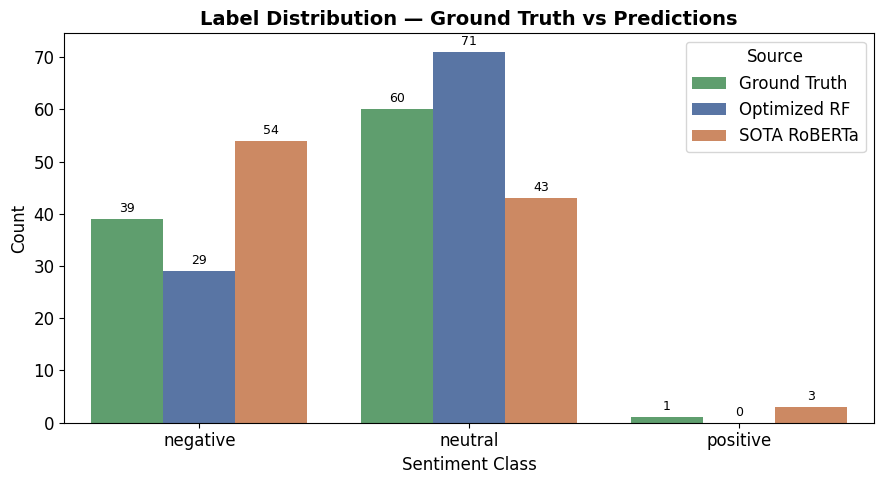

Saved: label_distribution_comparison.png


In [105]:
dist_data = pd.DataFrame({
    'Label': labels * 3,
    'Count': [
        (y_true == c).sum() for c in labels
    ] + [
        (y_rf == c).sum() for c in labels
    ] + [
        (y_sota == c).sum() for c in labels
    ],
    'Source': ['Ground Truth'] * 3 + ['Optimized RF'] * 3 + ['SOTA RoBERTa'] * 3
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=dist_data, x='Label', y='Count', hue='Source',
            palette=[COLORS['gt'], COLORS['rf'], COLORS['sota']], ax=ax)
ax.set_title('Label Distribution \u2014 Ground Truth vs Predictions', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Sentiment Class')
ax.legend(title='Source')

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

plt.tight_layout()
plt.savefig(VISUALS_OUT / 'label_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: label_distribution_comparison.png')

### Insight: Prediction Distribution

This chart reveals each model's class bias by comparing predicted label distributions against the ground truth:

- **Ground truth:** 39 negative, 60 neutral, 1 positive — a heavily skewed distribution typical of social media sentiment data.
- **RF predictions:** 29 negative, 71 neutral, 0 positive. RF over-predicts neutral (+11 vs ground truth) and under-predicts negative (-10). It never predicts positive, confirming its inability to detect minority-class sentiment despite class weighting.
- **SOTA predictions:** 54 negative, 43 neutral, 3 positive. SOTA swings in the opposite direction — it over-predicts negative (+15) and under-predicts neutral (-17). However, it does predict positive (3 times) where ground truth has 1, showing sensitivity to positive sentiment at the cost of some false positives.

The distribution patterns align with each model's architecture: RF with GloVe averaging tends toward the dominant class, while RoBERTa's fine-tuned attention captures more nuanced sentiment signals, even if imprecisely.

## Cell 16: Confidence Distribution

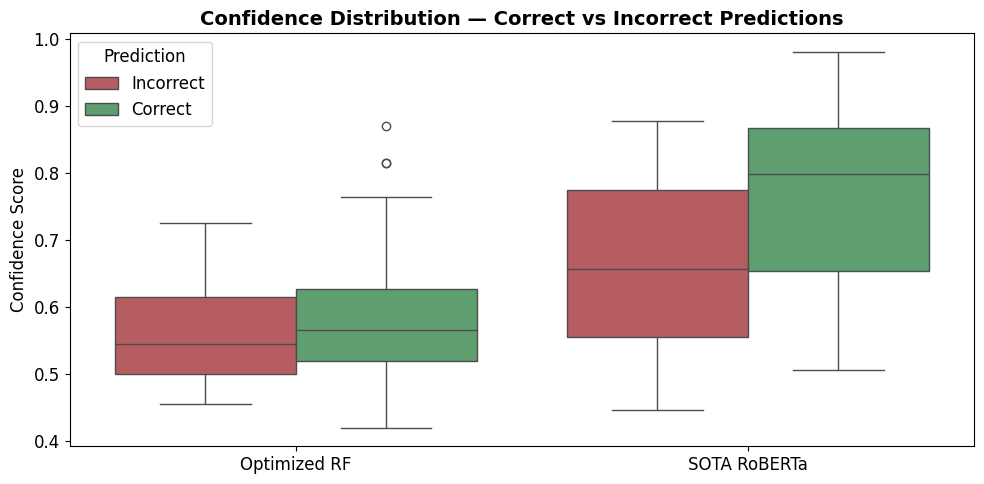

Saved: confidence_distribution.png


In [106]:
# Build confidence data with correct/incorrect labels
conf_df = pd.DataFrame({
    'Confidence': pd.concat([df.loc[valid_mask, 'rf_confidence'], df.loc[valid_mask, 'sota_confidence']], ignore_index=True),
    'Model': ['Optimized RF'] * valid_mask.sum() + ['SOTA RoBERTa'] * valid_mask.sum(),
    'Correct': (
        list((y_true.values == y_rf.values).astype(str)) +
        list((y_true.values == y_sota.values).astype(str))
    )
})
conf_df['Correct'] = conf_df['Correct'].map({'True': 'Correct', 'False': 'Incorrect'})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=conf_df, x='Model', y='Confidence', hue='Correct',
            palette={'Correct': '#55A868', 'Incorrect': '#C44E52'}, ax=ax)
ax.set_title('Confidence Distribution \u2014 Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
ax.set_ylabel('Confidence Score')
ax.set_xlabel('')
ax.legend(title='Prediction')

plt.tight_layout()
plt.savefig(VISUALS_OUT / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: confidence_distribution.png')

### Insight: Confidence Distribution

The confidence box plots reveal important calibration differences:

- **RF confidence** is tightly clustered in a narrow range (~0.42–0.87), with little separation between correct and incorrect predictions. This suggests the Random Forest model is **poorly calibrated** — it is not much more confident when it is right than when it is wrong. The tight range reflects the averaging effect of GloVe embeddings, which produce similar feature vectors for semantically related texts.
- **SOTA RoBERTa** shows a wider confidence range (~0.45–0.98) and better separation between correct and incorrect predictions. Correct predictions tend to have higher confidence, indicating **better calibration**. The model "knows what it knows" more reliably.

This has practical implications: SOTA's confidence scores could be used as a meaningful threshold for flagging uncertain predictions in a production system, whereas RF's confidence scores provide less actionable signal.